In [1]:
import pandas as pd
df=pd.read_csv("Ecommerce_Cleaned_Data.csv")
print(df.shape)
df.columns
df.info()

(779425, 9)
<class 'pandas.DataFrame'>
RangeIndex: 779425 entries, 0 to 779424
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      779425 non-null  int64  
 1   StockCode    779425 non-null  str    
 2   Description  779425 non-null  str    
 3   Quantity     779425 non-null  int64  
 4   Price        779425 non-null  float64
 5   Customer ID  779425 non-null  int64  
 6   Country      779425 non-null  str    
 7   Revenue      779425 non-null  float64
 8   InvoiceDate  779425 non-null  str    
dtypes: float64(2), int64(3), str(4)
memory usage: 53.5 MB


In [2]:
df.head(5)

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country,Revenue,InvoiceDate
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,13085,United Kingdom,83.4,2009-12-01 07:45:00
1,489434,79323P,PINK CHERRY LIGHTS,12,6.75,13085,United Kingdom,81.0,2009-12-01 07:45:00
2,489434,79323W,WHITE CHERRY LIGHTS,12,6.75,13085,United Kingdom,81.0,2009-12-01 07:45:00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2.10,13085,United Kingdom,100.8,2009-12-01 07:45:00
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.25,13085,United Kingdom,30.0,2009-12-01 07:45:00


In [3]:
# Data Quality Check
df.isnull().sum()
df[df.duplicated()]
# Count Quantity <= 0
df[df['Quantity'] <= 0]
negative_price=df[df['Price'] <= 0]
print(negative_price.shape[0])
print(negative_price.head(5))


0
Empty DataFrame
Columns: [Invoice, StockCode, Description, Quantity, Price, Customer ID, Country, Revenue, InvoiceDate]
Index: []


In [4]:
# columns name modified
df.columns=df.columns.str.lower().str.replace(" ","_")

In [5]:
df.head(5)

,invoice,stockcode,description,quantity,price,customer_id,country,revenue,invoicedate
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,13085,United Kingdom,83.4,2009-12-01 07:45:00
1,489434,79323P,PINK CHERRY LIGHTS,12,6.75,13085,United Kingdom,81.0,2009-12-01 07:45:00
2,489434,79323W,WHITE CHERRY LIGHTS,12,6.75,13085,United Kingdom,81.0,2009-12-01 07:45:00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2.10,13085,United Kingdom,100.8,2009-12-01 07:45:00
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.25,13085,United Kingdom,30.0,2009-12-01 07:45:00


In [6]:
df['calculated_revenue']=df['quantity']*df['price']
revenue_check=(df['revenue'].round(2) ==df['calculated_revenue'].round(2)).all()
print(revenue_check)
df.drop(columns=['calculated_revenue'],inplace=True)

True


In [7]:
df['invoicedate']=pd.to_datetime(df['invoicedate'])
df['year']=df['invoicedate'].dt.year
df['month']=df['invoicedate'].dt.month
df['month_name']=df['invoicedate'].dt.month_name()
df['day']=df['invoicedate'].dt.day
df['weekday']=df['invoicedate'].dt.day_name()

In [8]:
df[['invoicedate','year','month','month_name','day','weekday']].head()

,invoicedate,year,month,month_name,day,weekday
0,2009-12-01 07:45:00,2009,12,December,1,Tuesday
1,2009-12-01 07:45:00,2009,12,December,1,Tuesday
2,2009-12-01 07:45:00,2009,12,December,1,Tuesday
3,2009-12-01 07:45:00,2009,12,December,1,Tuesday
4,2009-12-01 07:45:00,2009,12,December,1,Tuesday


In [9]:
# Descriptive Statistics(quantity,price,revenue)
ds=df[['quantity','price','revenue']].describe()
print(ds)

            quantity          price        revenue
count  779425.000000  779425.000000  779425.000000
mean       13.489370       3.218488      22.291823
std       145.855814      29.676140     227.427075
min         1.000000       0.001000       0.001000
25%         2.000000       1.250000       4.950000
50%         6.000000       1.950000      12.480000
75%        12.000000       3.750000      19.800000
max     80995.000000   10953.500000  168469.600000


In [10]:
df[df['quantity']==80995] 
# this is valide because it may be bulk order not incorrect entry

,invoice,stockcode,description,quantity,price,customer_id,country,revenue,invoicedate,year,month,month_name,day,weekday
778958,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,16446,United Kingdom,168469.6,2011-12-09 09:15:00,2011,12,December,9,Friday


In [11]:
# Customer Analysis
customer_summary=df.groupby('customer_id').agg(total_orders=('invoice','nunique'),total_quantity=('quantity','sum'),       
total_revenue=('revenue','sum')          
).reset_index()
customer_summary = customer_summary.sort_values('total_revenue',ascending=False)
print(customer_summary.head(10))

      customer_id  total_orders  total_quantity  total_revenue
5692        18102           145          181645      580987.04
2277        14646           151          367193      528602.52
1789        14156           156          164325      313437.62
2538        14911           398          147972      291420.81
5050        17450            51           83914      244784.25
1331        13694           143          188201      195640.69
5109        17511            60          117174      172132.87
4061        16446             2           80997      168472.50
4295        16684            55          104810      147142.77
68          12415            28           91447      144458.37


In [12]:
# Customer Revenue Distribution
print(customer_summary['total_revenue'].describe())

count      5878.000000
mean       2955.904095
std       14440.852688
min           2.950000
25%         342.280000
50%         867.740000
75%        2248.305000
max      580987.040000
Name: total_revenue, dtype: float64


In [13]:
# RFM Analysis
max_dataset_date=df['invoicedate'].max()

rfm_summary=df.groupby('customer_id').agg(recency=('invoicedate',lambda x:(max_dataset_date- x.max()).days),
frequency=('invoice','nunique'),
monetary=('revenue','sum')).reset_index()


print(rfm_summary.head(10))

   customer_id  recency  frequency  monetary
0        12346      325         12  77556.46
1        12347        1          8   4921.53
2        12348       74          5   2019.40
3        12349       18          4   4428.69
4        12350      309          1    334.40
5        12351      374          1    300.93
6        12352       35         10   2849.84
7        12353      203          2    406.76
8        12354      231          1   1079.40
9        12355      213          2    947.61


In [14]:
# RFM Scoring in Python

rfm_summary['r_score'] = pd.qcut(rfm_summary['recency'].rank(method='first'),5,labels=[5,4,3,2,1]).astype(int)

rfm_summary['f_score'] = pd.qcut(rfm_summary['frequency'].rank(method='first'),5,labels=[1,2,3,4,5]).astype(int)

rfm_summary['m_score'] = pd.qcut(rfm_summary['monetary'].rank(method='first'),5,labels=[1,2,3,4,5]).astype(int)


rfm_summary['rfm_score']=rfm_summary['r_score']*100+rfm_summary['f_score']*10+rfm_summary['m_score']

print(rfm_summary.head())

   customer_id  recency  frequency  monetary  r_score  f_score  m_score  \
0        12346      325         12  77556.46        2        5        5   
1        12347        1          8   4921.53        5        4        5   
2        12348       74          5   2019.40        3        4        4   
3        12349       18          4   4428.69        5        3        5   
4        12350      309          1    334.40        2        1        2   

   rfm_score  
0        255  
1        545  
2        344  
3        535  
4        212  


In [15]:
# Customer Segmentation
import numpy as np
conditions=[(rfm_summary['r_score'] >=4)&(rfm_summary['f_score'] >=4)&(rfm_summary['m_score']>= 4),   
(rfm_summary['r_score'] >=3) &(rfm_summary['f_score'] >=4),                                  
(rfm_summary['r_score']>= 4)& (rfm_summary['f_score'] <=3),                                 
(rfm_summary['r_score'] <=2)& (rfm_summary['f_score'] >=3),                       
(rfm_summary['r_score'] <=2)&(rfm_summary['f_score'] <=2), ]

choices=['Champions','Loyal Customers','Potential Loyalists','At Risk','Lost Customers']

rfm_summary['customer_segment']=np.select(conditions, choices, default='Others')

print(rfm_summary[['customer_id','r_score','f_score','m_score','customer_segment']].head(10))

   customer_id  r_score  f_score  m_score     customer_segment
0        12346        2        5        5              At Risk
1        12347        5        4        5            Champions
2        12348        3        4        4      Loyal Customers
3        12349        5        3        5  Potential Loyalists
4        12350        2        1        2       Lost Customers
5        12351        2        1        2       Lost Customers
6        12352        4        5        4            Champions
7        12353        2        2        2       Lost Customers
8        12354        2        1        3       Lost Customers
9        12355        2        2        3       Lost Customers


In [16]:
# RFM Segment Summary
segment_summary=(rfm_summary.groupby('customer_segment').agg(customer_count=('customer_id','nunique'),
total_revenue=('monetary','sum'),
avg_revenue_per_customer=('monetary','mean'))
.sort_values('total_revenue', ascending=False).reset_index())

print(segment_summary)                                                           

      customer_segment  customer_count  total_revenue  \
0            Champions            1289   1.181963e+07   
1      Loyal Customers             708   1.895631e+06   
2              At Risk             825   1.590385e+06   
3  Potential Loyalists             878   8.699248e+05   
4       Lost Customers            1526   6.554447e+05   
5               Others             652   5.437919e+05   

   avg_revenue_per_customer  
0               9169.609678  
1               2677.445445  
2               1927.738887  
3                990.802746  
4                429.518140  
5                834.036722  


In [17]:
# Percentage of revenue by customer segment
segment_summary['revenue_pct']=(segment_summary['total_revenue'] /segment_summary['total_revenue'].sum())* 100

print(segment_summary[['customer_segment','revenue_pct']])


      customer_segment  revenue_pct
0            Champions    68.027396
1      Loyal Customers    10.910232
2              At Risk     9.153396
3  Potential Loyalists     5.006818
4       Lost Customers     3.772386
5               Others     3.129773


In [18]:
# Product Analysis
product_summary=(df.groupby(['stockcode','description']).agg(total_quantity=('quantity','sum'),
total_orders=('invoice','nunique'),total_revenue=('revenue','sum')).sort_values('total_revenue', ascending=False)
.reset_index())

print(product_summary.head(10))

  stockcode                         description  total_quantity  total_orders  \
0     22423            REGENCY CAKESTAND 3 TIER           24124          3317   
1    85123A  WHITE HANGING HEART T-LIGHT HOLDER           91757          4888   
2     23843         PAPER CRAFT , LITTLE BIRDIE           80995             1   
3         M                              Manual            9384           620   
4    85099B             JUMBO BAG RED RETROSPOT           74224          2612   
5      POST                             POSTAGE            5235          1803   
6     84879       ASSORTED COLOUR BIRD ORNAMENT           78234          2652   
7     47566                       PARTY BUNTING           23460          2077   
8     23166      MEDIUM CERAMIC TOP STORAGE JAR           77916           195   
9     22086     PAPER CHAIN KIT 50'S CHRISTMAS            28380          1691   

   total_revenue  
0      277656.25  
1      247048.01  
2      168469.60  
3      151777.67  
4      134307

In [19]:
# Country Analysis
country_summary=(df.groupby('country').agg(customer_count=('customer_id','nunique'),
total_orders=('invoice','nunique'),total_revenue=('revenue','sum')).sort_values('total_revenue', ascending=False)
.reset_index()).head(10)

print(country_summary)

          country  customer_count  total_orders  total_revenue
0  United Kingdom            5350         33541   1.438923e+07
1            EIRE               5           567   6.165705e+05
2     Netherlands              22           228   5.540381e+05
3         Germany             107           789   4.250197e+05
4          France              95           614   3.487690e+05
5       Australia              15            95   1.692835e+05
6           Spain              41           154   1.083325e+05
7     Switzerland              22            90   1.000619e+05
8          Sweden              19           104   9.151582e+04
9         Denmark              12            43   6.858069e+04


In [20]:
# Sales Trend Analysis
monthly_summary=(df.groupby(['year','month','month_name']).agg(total_quantity=('quantity','sum'),
total_orders=('invoice','nunique'),total_revenue=('revenue','sum')).sort_values(['year','month'])
.reset_index())

print(monthly_summary)

    year  month month_name  total_quantity  total_orders  total_revenue
0   2009     12   December          398660          1512     683504.010
1   2010      1    January          370082          1011     555802.672
2   2010      2   February          371861          1104     504558.956
3   2010      3      March          502100          1524     696978.471
4   2010      4      April          350587          1329     591982.002
5   2010      5        May          384960          1377     597833.380
6   2010      6       June          389872          1497     636371.130
7   2010      7       July          324632          1381     589736.170
8   2010      8     August          452542          1293     602224.600
9   2010      9  September          567153          1689     829013.951
10  2010     10    October          596432          2133    1033112.010
11  2010     11   November          653068          2587    1166460.022
12  2010     12   December          311048          1400     570

In [21]:
# Revenue & Customer Analysis

avg_revenue=customer_summary['total_revenue'].mean()
median_revenue=customer_summary['total_revenue'].median()

avg_orders=customer_summary['total_orders'].mean()
median_orders=customer_summary['total_orders'].median()

print("Average Revenue:",avg_revenue)
print("Median Revenue:",median_revenue)
print("Average Orders:",avg_orders)
print("Median Orders:",median_orders)

Average Revenue: 2955.9040945899965
Median Revenue: 867.74
Average Orders: 6.289384144266758
Median Orders: 3.0


In [22]:
# Outlier Analysis for revenue customer_summary(above calculated)
Q1=customer_summary['total_revenue'].quantile(0.25)
Q3=customer_summary['total_revenue'].quantile(0.75)
IQR=Q3-Q1

# (Statistics)
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR

above_upper_bound=(customer_summary['total_revenue'] > upper_bound).sum()
print("Q1:",Q1)
print("Q3:",Q3)
print("IQR:",IQR)
print("Lower Bound:",lower_bound)
print("Upper Bound:",upper_bound)
print("Customers above Upper Bound:",above_upper_bound)

Q1: 342.28
Q3: 2248.305
IQR: 1906.0249999999999
Lower Bound: -2516.7574999999997
Upper Bound: 5107.3425
Customers above Upper Bound: 633


In [23]:
# high value customer details
high_value_customers=(customer_summary[customer_summary['total_revenue'] >upper_bound]
.sort_values('total_revenue',ascending=False))
print(high_value_customers.head(10))


      customer_id  total_orders  total_quantity  total_revenue
5692        18102           145          181645      580987.04
2277        14646           151          367193      528602.52
1789        14156           156          164325      313437.62
2538        14911           398          147972      291420.81
5050        17450            51           83914      244784.25
1331        13694           143          188201      195640.69
5109        17511            60          117174      172132.87
4061        16446             2           80997      168472.50
4295        16684            55          104810      147142.77
68          12415            28           91447      144458.37


In [24]:
# Revenue contribution of high-value customers
high_value_revenue=high_value_customers['total_revenue'].sum()
total_revenue_all=customer_summary['total_revenue'].sum()

percentage_contribution=(high_value_revenue / total_revenue_all) * 100

print("High-value customers revenue:",high_value_revenue)
print("Total customer revenue:",total_revenue_all)
print("Contribution (%):",percentage_contribution)


High-value customers revenue: 11344751.358000001
Total customer revenue: 17374804.268
Contribution (%): 65.29426854548322


In [25]:
# Standard deviation of customer revenue
std_revenue=customer_summary['total_revenue'].std()
print("Standard Deviation of Customer Revenue:",std_revenue)

Standard Deviation of Customer Revenue: 14440.852688119263


In [26]:
# Python visualization
import matplotlib.pyplot as plt

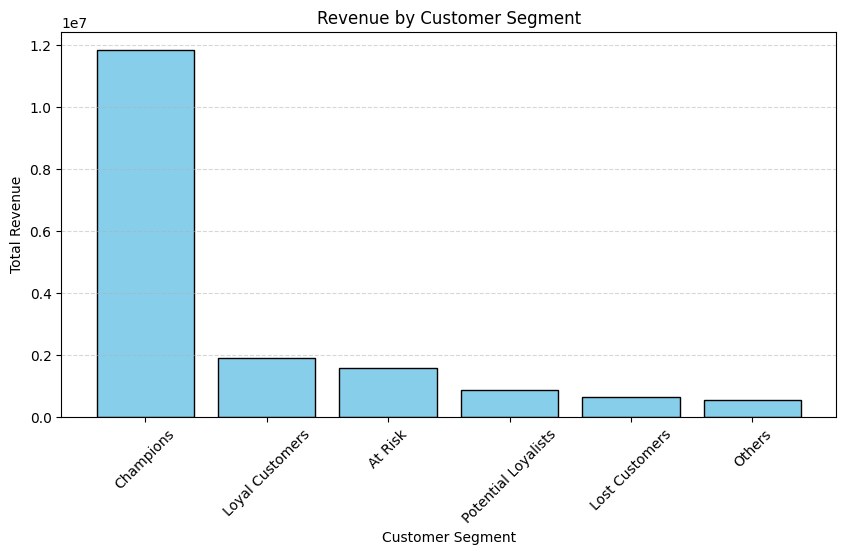

In [27]:
# customer segment using segment_summary
# X-axis: customer_segment
# Y-axis: total_revenue
plt.figure(figsize=(10,5))
plt.bar(segment_summary['customer_segment'],segment_summary['total_revenue'],color='skyblue',edgecolor='black')
plt.title('Revenue by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid(axis='y',linestyle='--',alpha=0.5)
plt.show()

In [28]:
# Correlation between orders, quantity, and revenue
correlation_matrix=customer_summary[['total_orders','total_quantity','total_revenue']].corr()

print(correlation_matrix)


                total_orders  total_quantity  total_revenue
total_orders        1.000000        0.571799       0.627920
total_quantity      0.571799        1.000000       0.874546
total_revenue       0.627920        0.874546       1.000000


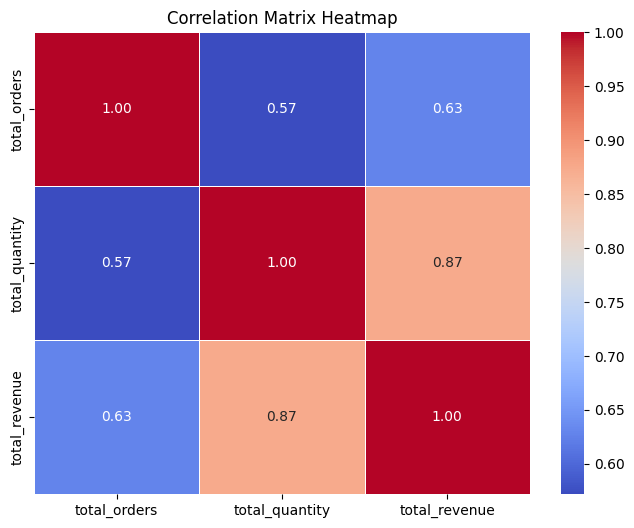

In [29]:
import seaborn as sns


# Select relevant columns
corr_matrix = customer_summary[['total_orders','total_quantity','total_revenue']].corr()

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()


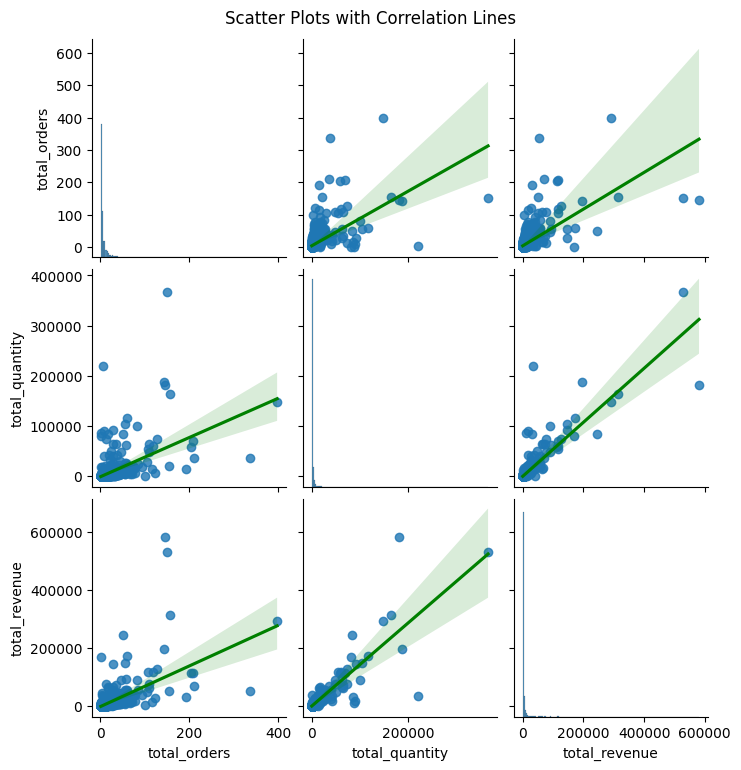

In [30]:
# Pairplot with regression lines
sns.pairplot(customer_summary[['total_orders','total_quantity','total_revenue']], 
             kind='reg', plot_kws={'line_kws':{'color':'green'}})
plt.suptitle("Scatter Plots with Correlation Lines", y=1.02)
plt.show()


In [31]:
rfm_summary

,customer_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,customer_segment
0,12346,325,12,77556.46,2,5,5,255,At Risk
1,12347,1,8,4921.53,5,4,5,545,Champions
2,12348,74,5,2019.40,3,4,4,344,Loyal Customers
3,12349,18,4,4428.69,5,3,5,535,Potential Loyalists
4,12350,309,1,334.40,2,1,2,212,Lost Customers
...,...,...,...,...,...,...,...,...,...
5873,18283,3,22,2664.90,5,5,4,554,Champions
5874,18284,431,1,461.68,1,2,2,122,Lost Customers
5875,18285,660,1,427.00,1,2,2,122,Lost Customers
5876,18286,476,2,1296.43,1,3,4,134,At Risk


In [32]:
df['customer_id'].nunique()

5878

In [33]:
df.head()

,invoice,stockcode,description,quantity,price,customer_id,country,revenue,invoicedate,year,month,month_name,day,weekday
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,13085,United Kingdom,83.4,2009-12-01 07:45:00,2009,12,December,1,Tuesday
1,489434,79323P,PINK CHERRY LIGHTS,12,6.75,13085,United Kingdom,81.0,2009-12-01 07:45:00,2009,12,December,1,Tuesday
2,489434,79323W,WHITE CHERRY LIGHTS,12,6.75,13085,United Kingdom,81.0,2009-12-01 07:45:00,2009,12,December,1,Tuesday
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2.10,13085,United Kingdom,100.8,2009-12-01 07:45:00,2009,12,December,1,Tuesday
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.25,13085,United Kingdom,30.0,2009-12-01 07:45:00,2009,12,December,1,Tuesday


In [34]:
df.to_csv("python_clean_data.csv", index=False)

In [35]:
rfm_summary.to_csv("RFM_Customer_Segmentation.csv", index=False)